In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [6]:
df=pd.read_csv('C:/Users/ankit/OneDrive/Desktop/Climate-Crop ML/data/climate-ds.csv')

In [7]:
df

,Unnamed: 0,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,hg/ha_yield
0,0,Albania,Maize,1990,1485,121.00,16.37,36613
1,1,Albania,Potatoes,1990,1485,121.00,16.37,66667
2,2,Albania,"Rice, paddy",1990,1485,121.00,16.37,23333
3,3,Albania,Sorghum,1990,1485,121.00,16.37,12500
4,4,Albania,Soybeans,1990,1485,121.00,16.37,7000
...,...,...,...,...,...,...,...,...
28237,28237,Zimbabwe,"Rice, paddy",2013,657,2550.07,19.76,22581
28238,28238,Zimbabwe,Sorghum,2013,657,2550.07,19.76,3066
28239,28239,Zimbabwe,Soybeans,2013,657,2550.07,19.76,13142
28240,28240,Zimbabwe,Sweet potatoes,2013,657,2550.07,19.76,22222


In [8]:
df.shape

(28242, 8)

In [9]:
df.columns

Index(['Unnamed: 0', 'Area', 'Item', 'Year', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp', 'hg/ha_yield'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  str    
 2   Item                           28242 non-null  str    
 3   Year                           28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  int64  
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
 7   hg/ha_yield                    28242 non-null  int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 1.7 MB


In [11]:
df.describe()

,Unnamed: 0,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,hg/ha_yield
count,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000,28242.000000
mean,14120.500000,2001.544296,1149.05598,37076.909344,20.542627,77053.332094
std,8152.907488,7.051905,709.81215,59958.784665,6.312051,84956.612897
min,0.000000,1990.000000,51.00000,0.040000,1.300000,50.000000
25%,7060.250000,1995.000000,593.00000,1702.000000,16.702500,19919.250000
50%,14120.500000,2001.000000,1083.00000,17529.440000,21.510000,38295.000000
75%,21180.750000,2008.000000,1668.00000,48687.880000,26.000000,104676.750000
max,28241.000000,2013.000000,3240.00000,367778.000000,30.650000,501412.000000


In [12]:
df.isnull().sum()

Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
hg/ha_yield                      0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [18]:
df = df.drop(["Unnamed: 0"], axis=1)

In [19]:
df.columns

Index(['Area', 'Item', 'average_rain_fall_mm_per_year', 'pesticides_tonnes',
       'avg_temp', 'hg/ha_yield'],
      dtype='str')

In [20]:
df["Item"].unique()

<StringArray>
[               'Maize',             'Potatoes',          'Rice, paddy',
              'Sorghum',             'Soybeans',                'Wheat',
              'Cassava',       'Sweet potatoes', 'Plantains and others',
                 'Yams']
Length: 10, dtype: str

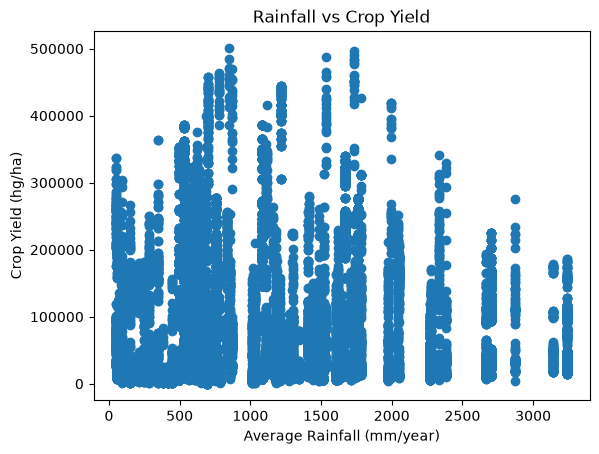

In [21]:
plt.scatter(
    df["average_rain_fall_mm_per_year"],
    df["hg/ha_yield"]
)

plt.xlabel("Average Rainfall (mm/year)")
plt.ylabel("Crop Yield (hg/ha)")
plt.title("Rainfall vs Crop Yield")

plt.show()

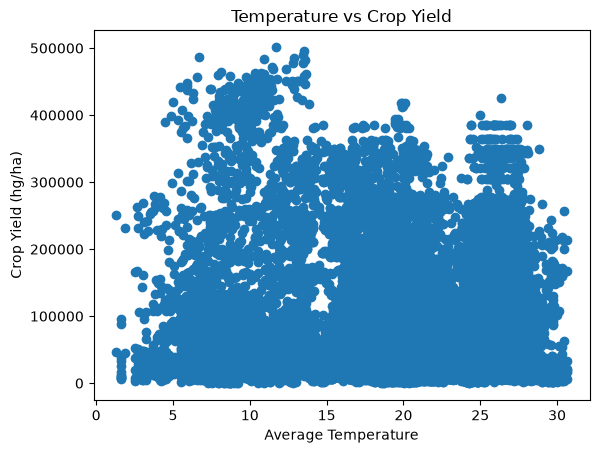

In [22]:
plt.scatter(
    df["avg_temp"],
    df["hg/ha_yield"]
)

plt.xlabel("Average Temperature")
plt.ylabel("Crop Yield (hg/ha)")
plt.title("Temperature vs Crop Yield")

plt.show()

In [26]:
area_encoder = LabelEncoder()
item_encoder = LabelEncoder()

df["Area"] = area_encoder.fit_transform(df["Area"])
df["Item"] = item_encoder.fit_transform(df["Item"])

In [49]:
joblib.dump(area_encoder, "../model/area_encoder.pkl")
joblib.dump(item_encoder, "../model/item_encoder.pkl")

['../model/item_encoder.pkl']

In [27]:
df.head()

,Area,Item,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,hg/ha_yield
0,0,1,1485,121.0,16.37,36613
1,0,3,1485,121.0,16.37,66667
2,0,4,1485,121.0,16.37,23333
3,0,5,1485,121.0,16.37,12500
4,0,6,1485,121.0,16.37,7000


In [28]:
X = df[
    [
        "Area",
        "Item",
        "average_rain_fall_mm_per_year",
        "pesticides_tonnes",
        "avg_temp"
    ]
]

y = df["hg/ha_yield"]

In [29]:
print(X.head())
print(y.head())

   Area  Item  average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp
0     0     1                           1485              121.0     16.37
1     0     3                           1485              121.0     16.37
2     0     4                           1485              121.0     16.37
3     0     5                           1485              121.0     16.37
4     0     6                           1485              121.0     16.37
0    36613
1    66667
2    23333
3    12500
4     7000
Name: hg/ha_yield, dtype: int64


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (22593, 5)
Testing data: (5649, 5)


In [32]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [33]:
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [45]:
import joblib

In [47]:
joblib.dump(model, "../model/yield_model.pkl")

['../model/yield_model.pkl']

In [34]:
y_pred = model.predict(X_test)

In [35]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

result.head(10)

,Actual,Predicted
0,69220,71055.92
1,20000,23774.67
2,51206,52358.26
3,166986,155304.15
4,56319,55865.50
5,26163,26163.00
6,30708,30636.60
7,109771,110394.89
8,241650,234894.75
9,47500,44428.38


In [36]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.9729083242793309


In [37]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 5626.0119946934765


In [38]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 14018.349718094098


In [39]:
print("Model Performance")
print("------------------")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

Model Performance
------------------
R2 Score: 0.9729083242793309
MAE: 5626.0119946934765
RMSE: 14018.349718094098


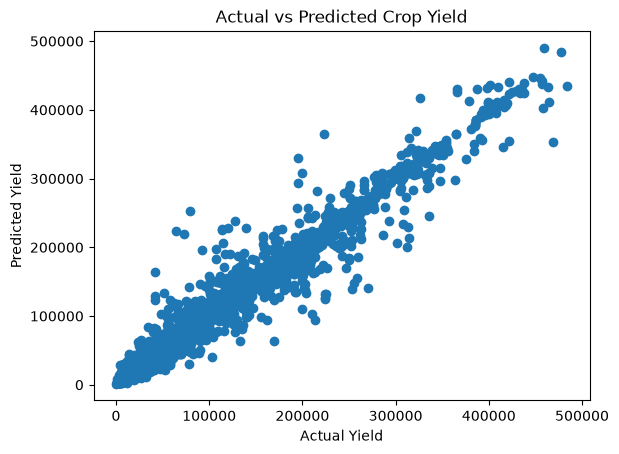

In [40]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield")

plt.show()

In [41]:
importance = model.feature_importances_

features = X.columns

for feature, value in zip(features, importance):
    print(feature, ":", value)

Area : 0.054729649884331315
Item : 0.6088433025659772
average_rain_fall_mm_per_year : 0.08782749219104358
pesticides_tonnes : 0.13295106100817589
avg_temp : 0.11564849435047199


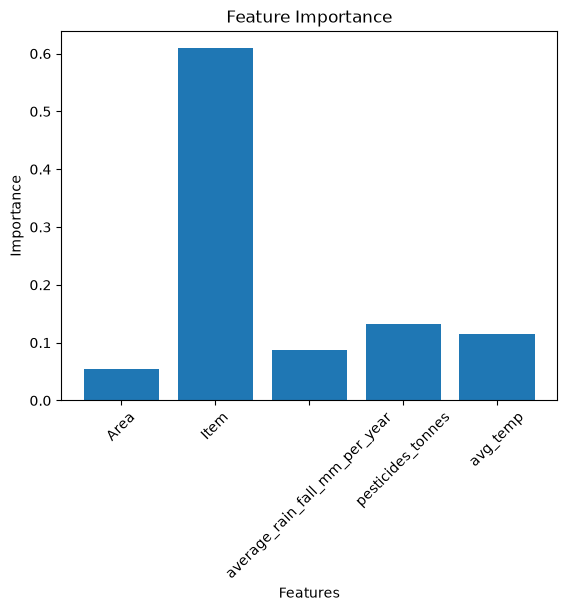

In [42]:
plt.bar(X.columns, model.feature_importances_)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.xticks(rotation=45)

plt.show()

In [43]:
sample = X.iloc[0:1]

prediction = model.predict(sample)

print("Predicted Yield:", prediction[0])

Predicted Yield: 33410.38


In [44]:
actual = y.iloc[0]

print("Actual Yield:", actual)
print("Predicted Yield:", prediction[0])

Actual Yield: 36613
Predicted Yield: 33410.38
